# Overview

This notebook demonstrates how to get started on a car price regression project using the carvana dataset I created: https://www.kaggle.com/datasets/ravishah1/carvana-predict-car-prices

For this notebook, I feature engineer the make and model of the car using a TFIDF vectorizer. Additional features include the year the car was made and the mileage of the car. I use an lightgbm model to use these features to calculate the price of the car on carvana

There are many ways to expand upon this notebook as this is a very simple starter. You can use a more advanced nlp techniques and models such as transformer neural networks. You perform more exploratory data analysis and find trends between different features and the price of the car. You can also test different models and hyperparameter tune them to achieve the best root mean squared error (rmse).

# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
import lightgbm as lgb 

In [2]:
df = pd.read_csv("/kaggle/input/carvana-predict-car-prices/carvana.csv")
df.head()

,Name,Year,Miles,Price
0,Chevrolet Trax,2018,41946,16990
1,GMC Terrain,2020,45328,23990
2,Jeep Wrangler,2012,81068,21590
3,Jeep Renegade,2019,35372,21590
4,BMW X,20173,68992,22990


### Metadata

In [3]:
print("samples:", len(df))
print()
print("nulls:")
print(df.isnull().sum())

samples: 22000

nulls:
Name     0
Year     0
Miles    0
Price    0
dtype: int64


### Mileage

[]

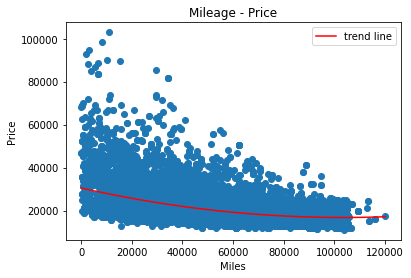

In [4]:
x = df.Miles
y = df.Price
a, b, c = np.polyfit(x, y, 2)

plt.scatter(x, y)
x = np.linspace(0, x.max(), 100)
plt.plot(x, a*(x**2)+b*x+c, color='red', label="trend line")
plt.title("Mileage - Price")
plt.xlabel("Miles")
plt.ylabel("Price")
plt.legend()
plt.plot()

### Year

It seems that there are some issues and outliers - lets correct them.

In [5]:
df.Year.max()

20223500

In [6]:
years = list()
for val in df.Year:
    if val > 2000 and val < 2030:
        years.append(val)
    else:
        years.append(np.nan)
df.Year = years

In [7]:
df.Year.value_counts()

2015.0    2542
2019.0    2281
2017.0    2152
2016.0    2107
2014.0    2053
2018.0    1684
2020.0    1232
2021.0    1160
2012.0    1149
2013.0    1126
2010.0     599
2011.0     556
2022.0     356
2009.0     150
2023.0       2
Name: Year, dtype: int64

# Model

### Setup Simple Validation

In [8]:
X = df[["Name", "Year", "Miles"]]
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Preprocess

In [9]:
vec = TfidfVectorizer()
embeddings = vec.fit_transform(X_train.Name)
temp_X_train = pd.DataFrame(embeddings.todense(), columns=vec.get_feature_names_out())
temp_X_train["Year"] = X_train["Year"]
temp_X_train["Miles"] = X_train["Miles"]
X_train = temp_X_train

embeddings = vec.transform(X_test.Name)
temp_X_test = pd.DataFrame(embeddings.todense(), columns=vec.get_feature_names_out())
temp_X_test["Year"] = X_test["Year"]
temp_X_test["Miles"] = X_test["Miles"]
X_test = temp_X_test

# Train

In [10]:
params = {
    "boosting_type": "gbdt",
    "objective": "mse",

    "learning_rate": 0.3,
    "max_depth": -1,
    "colsample_bytree": .85,
    "subsample": .85,

    "num_boost_round": 10000,
    
    "random_state": 42,
    "n_jobs": -1,
}

model = lgb.LGBMRegressor(**params)

In [11]:
model.fit(X_train, y_train)
oos = model.predict(X_test)
print()
print('rmse:', np.sqrt(mean_squared_error(y_test, oos)))

/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:177: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] num_iterations is set=10000, num_boost_round=10000 will be ignored. Current value: num_iterations=10000

rmse: 4625.854076269468
